# SS24 circularization efficiency

This notebook reproduces the instantaneous normalization used by Steinberg & Stone (2024),

\[
\chi(t)=\frac{-\dot E_{\rm orb,bound}}{\dot M_{\rm fb}(t)\,\Delta\epsilon_{\rm circ}},
\qquad
\Delta\epsilon_{\rm circ}=\frac{GM_\bullet}{4R_p}.
\]

The fallback rate is inferred from the simulated debris-energy distribution at 0.40 d and 23.17 d using
\(\dot M_{\rm fb}=({\rm d}M/{\rm d}\epsilon)|{\rm d}\epsilon/{\rm d}t|\).
The existing `Ediss-t` and `epsilondiss-t` workflows are not modified.

For a direct check, the published red curve is recovered from the official vector asset for Figure 2:
[paper](https://arxiv.org/abs/2206.10641), [Figure 2 SVG](https://arxiv.org/html/2206.10641v2/Mb.svg).
It is figure-extracted reference data, not author-supplied tabular source data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import unyt as u
from scipy.signal import savgol_filter

REPO = Path("/home/hey4/rich_tde")
sys.path.insert(0, str(REPO))
import richio

DATA_DIR = REPO / "data/processed/SS24-circularization-t"
FIGURE_DIR = DATA_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES = DATA_DIR / "SS24-circularization-t-1e6.txt"
FALLBACK_FILES = {
    "0.40 d (snap 239)": DATA_DIR / "fallback-rate-snap239-0.40d.txt",
    "23.17 d (snap 712)": DATA_DIR / "fallback-rate-snap712-23.17d.txt",
}
SS24_REFERENCE = DATA_DIR / "SS24-Figure2-chi-vector-extracted.txt"

MSTAR = 1.0 * richio.units.mscale
MBH = 1.0e6 * richio.units.mscale
RSTAR = 1.0 * richio.units.lscale
RP = RSTAR * (MBH / MSTAR) ** (1 / 3)
DELTA_EPSILON_CIRC = (u.G * MBH / (4 * RP)).to("erg/g")
TMIN = (
    np.pi / np.sqrt(2)
    * (RSTAR**3 / u.G / MSTAR) ** 0.5
    * (MBH / MSTAR) ** 0.5
).to("day")

SMOOTHING_DAYS = 0.75
SMOOTHING_CHECKS_DAYS = (0.50, 0.75, 1.25)
print(f"t_min = {TMIN:.4g}; Delta epsilon_circ = {DELTA_EPSILON_CIRC:.4g}")

t_min = 41.22 day; Delta epsilon_circ = 4.767e+18 erg/g


In [2]:
def load_numeric(path, expected_columns):
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the SS24 Slurm study first.")
    values = np.atleast_2d(np.loadtxt(path))
    if values.shape[1] != expected_columns:
        raise ValueError(f"{path} has {values.shape[1]} columns; expected {expected_columns}")
    if not np.isfinite(values).all():
        raise ValueError(f"{path} contains NaN or infinity")
    return values

series = load_numeric(TIMESERIES, 7)
if not np.array_equal(series[:, 0], series[:, 0].astype(int)):
    raise ValueError("Non-integer snapshot number in the time series")
if np.any(np.diff(series[:, 2]) <= 0):
    raise ValueError("The SS24 time series is not strictly increasing in time")

fallback = {}
for label, path in FALLBACK_FILES.items():
    values = load_numeric(path, 6)
    order = np.argsort(values[:, 0])
    fallback[label] = {
        "return_day": values[order, 0],
        "mdot_raw": values[order, 4],
        "mdot_smooth": values[order, 5],
    }

reference = load_numeric(SS24_REFERENCE, 2)
print(f"Loaded {len(series)} SS24 snapshots from {series[0,2]:.2f} to {series[-1,2]:.2f} d")
print(f"Loaded {len(reference)} vector points from published Figure 2")

Loaded 198 SS24 snapshots from 35.24 to 64.44 d
Loaded 166 vector points from published Figure 2


0.40 d (snap 239): fallback peak at 55.04 d, 1.71 Msun/yr
23.17 d (snap 712): fallback peak at 59.34 d, 1.57 Msun/yr
0.40 d vs 23.17 d fallback curves, 25--65 d: median |fractional difference| = 22.96%


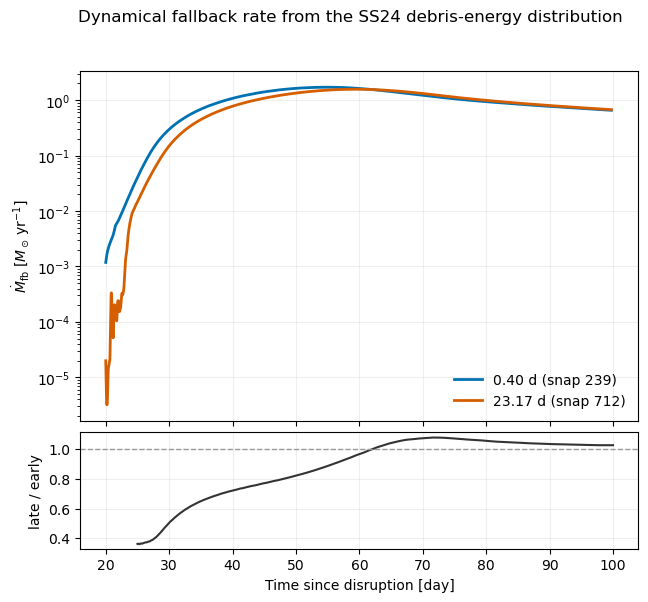

In [3]:
fig, (ax, ratio_ax) = plt.subplots(
    2, 1, figsize=(7.2, 6.2), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)
colors = ("#0072B2", "#D55E00")
profiles = list(fallback.items())
for color, (label, profile) in zip(colors, profiles):
    good = (
        (profile["return_day"] >= 20)
        & (profile["return_day"] <= 100)
        & (profile["mdot_smooth"] > 0)
    )
    ax.plot(
        profile["return_day"][good],
        profile["mdot_smooth"][good],
        color=color,
        lw=2,
        label=label,
    )

common_t = np.linspace(25, 100, 1000)
mdot_early = np.interp(
    common_t, profiles[0][1]["return_day"], profiles[0][1]["mdot_smooth"]
)
mdot_late = np.interp(
    common_t, profiles[1][1]["return_day"], profiles[1][1]["mdot_smooth"]
)
fallback_ratio = mdot_late / mdot_early
ratio_ax.plot(common_t, fallback_ratio, color="0.2")
ratio_ax.axhline(1, color="0.6", ls="--", lw=1)

for label, profile in profiles:
    mask = (profile["return_day"] >= 20) & (profile["return_day"] <= 100)
    peak_index = np.nanargmax(np.where(mask, profile["mdot_smooth"], np.nan))
    print(
        f"{label}: fallback peak at {profile['return_day'][peak_index]:.2f} d, "
        f"{profile['mdot_smooth'][peak_index]:.3g} Msun/yr"
    )

comparison = (common_t >= 25) & (common_t <= 65)
fractional_difference = np.abs(mdot_late[comparison] / mdot_early[comparison] - 1)
print(
    "0.40 d vs 23.17 d fallback curves, 25--65 d: "
    f"median |fractional difference| = {np.nanmedian(fractional_difference):.2%}"
)

ax.set_yscale("log")
ax.set_ylabel(r"$\dot M_{\rm fb}$ [$M_\odot\,\mathrm{yr}^{-1}$]")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ratio_ax.set_xlabel("Time since disruption [day]")
ratio_ax.set_ylabel("late / early")
ratio_limits = np.nanpercentile(fallback_ratio, [1, 99])
ratio_padding = 0.05 * np.diff(ratio_limits)[0]
ratio_ax.set_ylim(max(0, ratio_limits[0] - ratio_padding), ratio_limits[1] + ratio_padding)
ratio_ax.grid(alpha=0.2)
fig.suptitle("Dynamical fallback rate from the SS24 debris-energy distribution")
fig.savefig(FIGURE_DIR / "SS24-fallback-rate-epoch-comparison.png", dpi=220, bbox_inches="tight")
plt.show()

In [4]:
time_day = series[:, 2]
eorb_bound = u.unyt_array(
    series[:, 4],
    "code_length**2*code_mass/code_time**2",
    registry=richio.units.registry,
).to_value("erg")
mbound = u.unyt_array(
    series[:, 5], "code_mass", registry=richio.units.registry
).to_value("Msun")
ediss_total = u.unyt_array(
    series[:, 6],
    "code_length**2*code_mass/code_time**3",
    registry=richio.units.registry,
).to_value("erg/s")

# SS24 report that the two fallback estimates nearly overlap.  Use the
# pre-fallback (23.17 d) distribution for the main normalization.
fallback_main = fallback["23.17 d (snap 712)"]
mdot_msun_year = np.interp(
    time_day,
    fallback_main["return_day"],
    fallback_main["mdot_smooth"],
    left=np.nan,
    right=np.nan,
)
mdot_g_s = (u.unyt_array(mdot_msun_year, "Msun/yr")).to_value("g/s")
normalization_power = mdot_g_s * DELTA_EPSILON_CIRC.to_value("erg/g")

def smoothed_energy_loss_rate(window_days):
    dt = np.median(np.diff(time_day))
    uniform_time = np.arange(time_day[0], time_day[-1] + 0.5 * dt, dt)
    uniform_energy = np.interp(uniform_time, time_day, eorb_bound)
    window = max(5, int(round(window_days / dt)))
    if window % 2 == 0:
        window += 1
    if window >= len(uniform_time):
        window = len(uniform_time) - (1 - len(uniform_time) % 2)
    smooth_energy = savgol_filter(uniform_energy, window, polyorder=3)
    loss_rate_uniform = -np.gradient(smooth_energy, uniform_time * 86400.0)
    return np.interp(time_day, uniform_time, loss_rate_uniform)

chi_by_window = {
    window: smoothed_energy_loss_rate(window) / normalization_power
    for window in SMOOTHING_CHECKS_DAYS
}
chi_orbital = chi_by_window[SMOOTHING_DAYS]
chi_low = np.nanmin(np.vstack(list(chi_by_window.values())), axis=0)
chi_high = np.nanmax(np.vstack(list(chi_by_window.values())), axis=0)
chi_shock_proxy = ediss_total / normalization_power

valid = np.isfinite(chi_orbital) & np.isfinite(normalization_power) & (normalization_power > 0)
print(f"Finite chi values: {valid.sum()} / {len(valid)}")

Finite chi values: 198 / 198


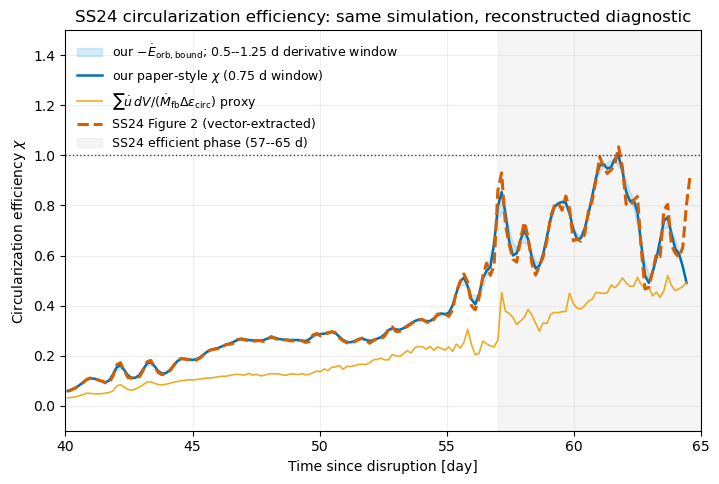

Median absolute difference from published curve: 0.004
RMS difference from published curve: 0.032
40 d: chi_orb= 0.056, chi_sum_diss= 0.030, SS24_Fig2= 0.058
47 d: chi_orb= 0.266, chi_sum_diss= 0.123, SS24_Fig2= 0.264
50 d: chi_orb= 0.286, chi_sum_diss= 0.137, SS24_Fig2= 0.281
55 d: chi_orb= 0.368, chi_sum_diss= 0.228, SS24_Fig2= 0.362
57 d: chi_orb= 0.784, chi_sum_diss= 0.260, SS24_Fig2= 0.834
60 d: chi_orb= 0.699, chi_sum_diss= 0.405, SS24_Fig2= 0.660
62 d: chi_orb= 0.889, chi_sum_diss= 0.499, SS24_Fig2= 0.865
64 d: chi_orb= 0.625, chi_sum_diss= 0.460, SS24_Fig2= 0.608


In [5]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))
plot_range = (time_day >= 40) & (time_day <= 65) & valid
ax.fill_between(
    time_day[plot_range],
    chi_low[plot_range],
    chi_high[plot_range],
    color="#56B4E9",
    alpha=0.25,
    label=r"our $-\dot E_{\rm orb,bound}$; 0.5--1.25 d derivative window",
)
ax.plot(
    time_day[plot_range],
    chi_orbital[plot_range],
    color="#0072B2",
    lw=1.8,
    label=rf"our paper-style $\chi$ ({SMOOTHING_DAYS:g} d window)",
)
ax.plot(
    time_day[plot_range],
    chi_shock_proxy[plot_range],
    color="#E69F00",
    lw=1.2,
    alpha=0.85,
    label=r"$\sum \dot u\,dV/(\dot M_{\rm fb}\Delta\epsilon_{\rm circ})$ proxy",
)
ax.plot(
    reference[:, 0],
    reference[:, 1],
    color="#D55E00",
    lw=2.2,
    ls="--",
    label="SS24 Figure 2 (vector-extracted)",
)
ax.axhline(1, color="0.25", ls=":", lw=1)
ax.axvspan(57, 65, color="0.5", alpha=0.08, label="SS24 efficient phase (57--65 d)")
ax.set_xlim(40, 65)
ax.set_ylim(-0.1, 1.5)
ax.set_xlabel("Time since disruption [day]")
ax.set_ylabel(r"Circularization efficiency $\chi$")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9, ncol=1)
ax.set_title("SS24 circularization efficiency: same simulation, reconstructed diagnostic")
fig.savefig(FIGURE_DIR / "SS24-circularization-efficiency-comparison.png", dpi=220, bbox_inches="tight")
plt.show()

common = (
    (time_day >= reference[:, 0].min())
    & (time_day <= reference[:, 0].max())
    & valid
)
reference_on_ours = np.interp(time_day[common], reference[:, 0], reference[:, 1])
difference = chi_orbital[common] - reference_on_ours
print(f"Median absolute difference from published curve: {np.median(np.abs(difference)):.3f}")
print(f"RMS difference from published curve: {np.sqrt(np.mean(difference**2)):.3f}")
for day in (40, 47, 50, 55, 57, 60, 62, 64):
    ours = np.interp(day, time_day[valid], chi_orbital[valid])
    shock = np.interp(day, time_day[valid], chi_shock_proxy[valid])
    published = np.interp(day, reference[:, 0], reference[:, 1])
    print(
        f"{day:>2} d: chi_orb={ours:6.3f}, "
        f"chi_sum_diss={shock:6.3f}, SS24_Fig2={published:6.3f}"
    )

## Interpretation guardrail

The blue curve is the definition used in the paper: the time derivative of the **total orbital energy of bound gas**, normalized by the energy needed to circularize newly returning mass. The orange curve instead uses the instantaneous sum of the stored dissipation field. Agreement between them is a useful energy-budget check, but they need not be identical because bound/unbound classification changes with time and because the orbital-energy derivative is temporally filtered.

Unlike the earlier \(P_R/M_R\) diagnostic, neither curve divides by a tiny instantaneous Eulerian region mass. A value above one can still occur instantaneously, but it now has the paper's precise meaning: dissipation faster than the rate needed to circularize only the *newly returning* debris at that moment.

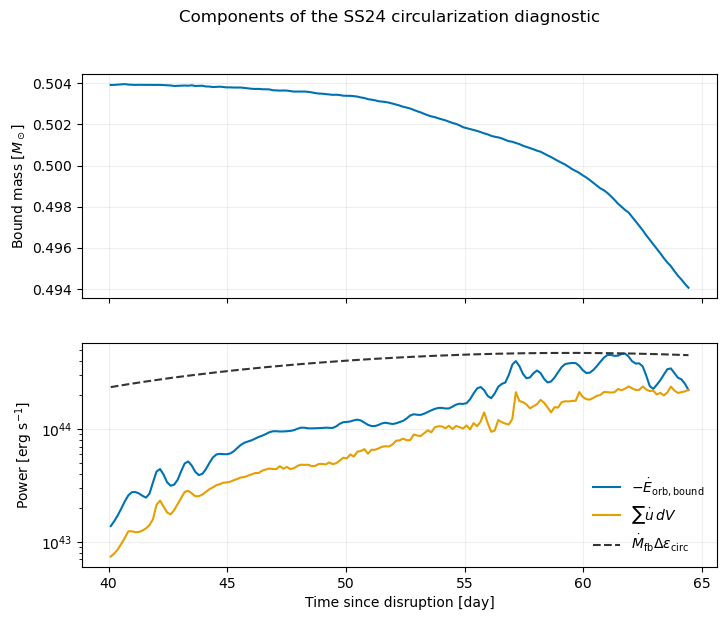

In [6]:
fig, (ax_mass, ax_power) = plt.subplots(2, 1, figsize=(8.2, 6.4), sharex=True)
show = (time_day >= 40) & (time_day <= 65)
ax_mass.plot(time_day[show], mbound[show], color="#0072B2")
ax_mass.set_ylabel(r"Bound mass [$M_\odot$]")
ax_mass.grid(alpha=0.2)

loss_rate = smoothed_energy_loss_rate(SMOOTHING_DAYS)
ax_power.plot(time_day[show], loss_rate[show], label=r"$-\dot E_{\rm orb,bound}$", color="#0072B2")
ax_power.plot(time_day[show], ediss_total[show], label=r"$\sum \dot u\,dV$", color="#E69F00")
ax_power.plot(
    time_day[show],
    normalization_power[show],
    label=r"$\dot M_{\rm fb}\Delta\epsilon_{\rm circ}$",
    color="0.2",
    ls="--",
)
ax_power.set_yscale("log")
ax_power.set_xlabel("Time since disruption [day]")
ax_power.set_ylabel("Power [erg s$^{-1}$]")
ax_power.grid(alpha=0.2)
ax_power.legend(frameon=False)
fig.suptitle("Components of the SS24 circularization diagnostic")
fig.savefig(FIGURE_DIR / "SS24-circularization-components.png", dpi=220, bbox_inches="tight")
plt.show()